## Research Question: Does recent performance prior to the tournament (last 5 games) correlate to the probability of a lower-seeded team upsetting a higher-seeded team?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

reg_season = pd.read_csv('MRegularSeasonCompactResults.csv')
tourney_results = pd.read_csv('MNCAATourneyCompactResults.csv')
seeds = pd.read_csv('MNCAATourneySeeds.csv')
df_teams = pd.read_csv('MTeams.csv')

winners = reg_season[['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore']].copy()
winners.columns = ['Season', 'DayNum', 'TeamID', 'Score', 'OpponentID', 'OpponentScore']
winners['Win'] = 1

losers = reg_season[['Season', 'DayNum', 'LTeamID', 'LScore', 'WTeamID', 'WScore']].copy()
losers.columns = ['Season', 'DayNum', 'TeamID', 'Score', 'OpponentID', 'OpponentScore']
losers['Win'] = 0

all_reg = pd.concat([winners, losers], ignore_index=True)
all_reg = all_reg.sort_values(['Season', 'TeamID', 'DayNum'], ascending=[True, True, False])

momentum = all_reg.groupby(['Season', 'TeamID']).head(5)
momentum_stats = momentum.groupby(['Season', 'TeamID'])['Win'].sum().reset_index()
momentum_stats.columns = ['Season', 'TeamID', 'Last5Wins']

seeds['SeedInt'] = seeds['Seed'].str.extract('(\d+)').astype(int)

tourney = pd.merge(tourney_results, seeds[['Season', 'TeamID', 'SeedInt']], 
                   left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']).rename(columns={'SeedInt': 'WSeed'}).drop('TeamID', axis=1)
tourney = pd.merge(tourney, seeds[['Season', 'TeamID', 'SeedInt']], 
                   left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID']).rename(columns={'SeedInt': 'LSeed'}).drop('TeamID', axis=1)

tourney = pd.merge(tourney, momentum_stats, left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']).rename(columns={'Last5Wins': 'WMomentum'}).drop('TeamID', axis=1)
tourney = pd.merge(tourney, momentum_stats, left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID']).rename(columns={'Last5Wins': 'LMomentum'}).drop('TeamID', axis=1)

tourney = tourney[tourney['WSeed'] != tourney['LSeed']].copy()

tourney['SeedDiff'] = abs(tourney['WSeed'] - tourney['LSeed'])
tourney = tourney[tourney['SeedDiff'] >= 5].copy()

def get_underdog_view(row):
    if row['WSeed'] > row['LSeed']:
        return pd.Series([row['WMomentum'], row['LMomentum'], 1])
    else:
        return pd.Series([row['LMomentum'], row['WMomentum'], 0])

analysis_df = tourney.apply(get_underdog_view, axis=1)
analysis_df.columns = ['UnderdogMomentum', 'FavoriteMomentum', 'UpsetOccurred']

final_report = analysis_df.groupby('UnderdogMomentum')['UpsetOccurred'].agg(['mean', 'count']).reset_index()

final_report.columns = ['Underdog Wins in Last 5', 'Upset Win Probability', 'Sample Size(Games)']

print(final_report)






   Underdog Wins in Last 5  Upset Win Probability  Sample Size(Games)
0                        1               0.350000                  40
1                        2               0.325758                 132
2                        3               0.238095                 315
3                        4               0.174004                 477
4                        5               0.195205                 584


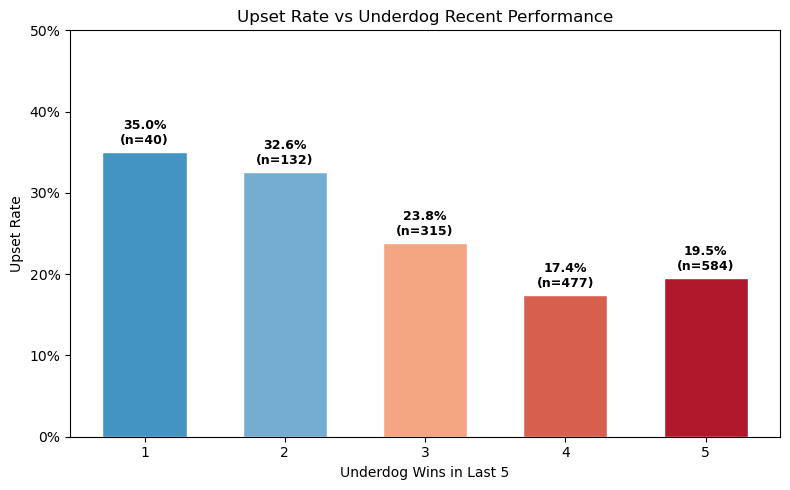

In [2]:
# plot upset rate vs underdog performance
fig, ax = plt.subplots(figsize=(8, 5))

final_report = final_report.sort_values('Underdog Wins in Last 5')

colors = ['#4393c3', '#74add1', '#f4a582', '#d6604d', '#b2182b']
bars = ax.bar(
    final_report['Underdog Wins in Last 5'].astype(str),
    final_report['Upset Win Probability'],
    edgecolor='white',
    width=0.6,
    color=colors
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 0.5)

ax.set_title('Upset Rate vs Underdog Recent Performance')
ax.set_xlabel('Underdog Wins in Last 5')
ax.set_ylabel('Upset Rate')

# Annotate bars with rate and sample size
for b, (_, r) in zip(bars, final_report.iterrows()):
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.01,
        f'{r["Upset Win Probability"]:.1%}\n(n={int(r["Sample Size(Games)"])})',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Conclusion

Conventionally, it is expected that teams who perform better going into the tournament have a natural "momentum" and flow going into the tournament, which should translate into winning more often. However, from this analysis, superior performance in the final five games of the regular season do not correlate with a higher upset probability. In fact, teams who have less wins in their final five regular season games have a higher upset win probability. Teams with 1 win have a 35% upset win probability, while teams with 4 wins and 5 wins have 17.89% and 19.58%, respectively, which is significantly lower.

This could be explained by the fact that these are raw upset rates, and do not take into account how different seed matchups affect the probability of an upset. For example, few, if any, 16 seeds in the tournament will have lost 4 of their last 5 games. This is because to make the tournament, they would have had to win their conference tournament, which involves winning multiple games in a row right at the end of the season. If buckets 4 and 5 receive most of the 16 seeds, their upset averages would be dragged down, as that upset is unlikely.

To account for this, we can compare the upset rates to the historical average upset rate for each seed matchup to see deviations.

In [3]:
# Create new columns for underdog and favorite seed and momentum
tourney['UnderdogSeed'] = tourney[['WSeed', 'LSeed']].max(axis=1)
tourney['FavoriteSeed'] = tourney[['WSeed', 'LSeed']].min(axis=1)
tourney['UnderdogMomentum'] = np.where(tourney['WSeed'] > tourney['LSeed'],
                                        tourney['WMomentum'],
                                        tourney['LMomentum'])
tourney['FavoriteMomentum'] = np.where(tourney['WSeed'] > tourney['LSeed'],
                                        tourney['LMomentum'],
                                        tourney['WMomentum'])
tourney['UpsetOccurred'] = (tourney['WSeed'] > tourney['LSeed']).astype(int)

# Calculate avg upset rate for each seed matchup (1v16, 12v5, etc.)
baseline_upset_rates = tourney.groupby(['UnderdogSeed', 'FavoriteSeed'])['UpsetOccurred'].agg(
    baseline_upset_rate='mean',
    total_games='count' # also keep track of how many games for each
).reset_index()

# merge baseline back
tourney = pd.merge(tourney, baseline_upset_rates, on=['UnderdogSeed', 'FavoriteSeed'], how='left')

# find difference between observed upset rates and historical upset rates
summary = tourney.groupby('UnderdogMomentum').agg(
    upset_rate=('UpsetOccurred', 'mean'),
    sample_size=('UpsetOccurred', 'count'),
    avg_baseline=('baseline_upset_rate', 'mean')
).reset_index()
summary['diff_from_baseline'] = summary['upset_rate'] - summary['avg_baseline']
print(summary)

   UnderdogMomentum  upset_rate  sample_size  avg_baseline  diff_from_baseline
0                 1    0.350000           40      0.285785            0.064215
1                 2    0.325758          132      0.263019            0.062739
2                 3    0.238095          315      0.247635           -0.009540
3                 4    0.174004          477      0.188227           -0.014223
4                 5    0.195205          584      0.197021           -0.001816


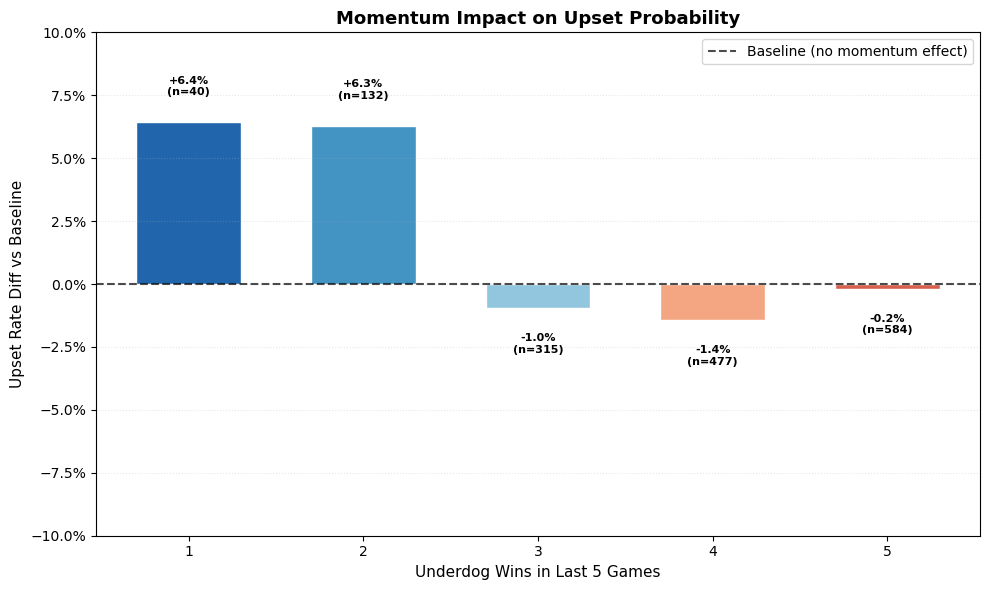

In [4]:
# Plot momentum impact relative to baseline
fig, ax = plt.subplots(figsize=(10, 6))

summary_sorted = summary.sort_values('UnderdogMomentum')

colors = ['#2166ac', '#4393c3', '#92c5de', '#f4a582', '#d6604d', '#b2182b']

bars = ax.bar(
    summary_sorted['UnderdogMomentum'].astype(str),
    summary_sorted['diff_from_baseline'],
    edgecolor='white',
    width=0.6,
    color=colors[:len(summary_sorted)]
)

# line at y=0 to indicate no effect
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline (no momentum effect)')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(-0.1, 0.1)

ax.set_title('Momentum Impact on Upset Probability',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Underdog Wins in Last 5 Games', fontsize=11)
ax.set_ylabel('Upset Rate Diff vs Baseline', fontsize=11)

# Annotate bars with diff, actual rate, and sample size
for b, (_, r) in zip(bars, summary_sorted.iterrows()):
    diff = r['diff_from_baseline']
    actual_rate = r['upset_rate']
    baseline = r['avg_baseline']
    n = int(r['sample_size'])

    # Position text above/below bar depending on sign
    y_pos = b.get_height() + 0.01 if diff >= 0 else b.get_height() - 0.01
    va = 'bottom' if diff >= 0 else 'top'

    ax.text(
        b.get_x() + b.get_width()/2,
        y_pos,
        f'{diff:+.1%}\n(n={n})',
        ha='center',
        va=va,
        fontsize=8,
        fontweight='bold'
    )

ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()